# 03_modeling / 01_feature_split_scale

`data/features/master_{full,p234}.csv` → 모델 학습 직전 (X, Y) 매트릭스.

**파이프라인**
1. 피처 엔지니어링 (Y lag/rolling, 외생 5개 lag/rolling, Y horizon)
2. Warmup row drop (60일)
3. Train/Val/Test 시점 분할 (DATE_SPLITS=['2024-01-01','2025-01-01'])
4. StandardScaler — train fold에서만 fit. X scaler 1개 + Y scaler horizon별 3개.
5. parquet 저장 + scalers joblib + feature_meta json

## 0. 셋업

In [1]:
import json
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

PROJECT_ROOT = Path('../..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features.engineering import add_lag_features, add_rolling_features, add_horizons
from src.features.split_scale import split_by_dates, fit_scaler, transform_x, fit_y_scalers, transform_y

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

## 1. 상수

In [2]:
Y_COL = 'KAU_CLOSE'
HORIZONS = [1, 5, 20]

LAG_Y = [1, 2, 3]
ROLL_Y_MEAN_WINDOWS = [5, 20, 60]
ROLL_Y_STD_WINDOWS = [5, 20]

SELECTED_EXOG = ['smp_window_mean', 'KRX_ENERGY', 'BOND_BBB', 'Oman', 'NEWCASTLE_COAL']
LAG_X = [1]
ROLL_X_MEAN_WINDOWS = [5, 20]

DATE_SPLITS = ['2024-01-01', '2025-01-01']
WARMUP_DROP = 60  # max(LAG_Y, LAG_X, ROLL_*_WINDOWS) = 60

# Passthrough (스케일링 제외)
DUMMY_COLS = ['is_traded', 'vintage_transition',
              'auction_dummy_pre5', 'auction_dummy_post5',
              'auction_dummy_pre2', 'auction_dummy_post2',
              'auction_day', 'ask_ratio_last_known']
INT_COUNT_COLS = ['smp_window_days', 'weather_window_days']
PASSTHROUGH_COLS = DUMMY_COLS + INT_COUNT_COLS

DROP_COLS = ['front_vintage']

OUT_DIR = PROJECT_ROOT / 'data' / 'features'
FIG_DIR = PROJECT_ROOT / 'reports' / 'figures' / 'modeling'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('피처 구성: Y lag', LAG_Y, '| Y roll mean', ROLL_Y_MEAN_WINDOWS, '| Y roll std', ROLL_Y_STD_WINDOWS)
print('외생 5개:', SELECTED_EXOG)
print('외생 lag', LAG_X, '| 외생 roll mean', ROLL_X_MEAN_WINDOWS)

피처 구성: Y lag [1, 2, 3] | Y roll mean [5, 20, 60] | Y roll std [5, 20]
외생 5개: ['smp_window_mean', 'KRX_ENERGY', 'BOND_BBB', 'Oman', 'NEWCASTLE_COAL']
외생 lag [1] | 외생 roll mean [5, 20]


## 2. 파이프라인 함수

In [3]:
def build_xy(dataset: pd.DataFrame):
    """feature engineering → warmup drop → X/Y 분리.

    Returns: (X_df, Y_df) 모두 DatetimeIndex 공유.
    """
    df = dataset.drop(columns=DROP_COLS).copy()

    # Y horizon 먼저 계산 (원본 KAU_CLOSE에서)
    df = add_horizons(df, Y_COL, HORIZONS)

    # Y lag/rolling
    df = add_lag_features(df, [Y_COL], LAG_Y)
    df = add_rolling_features(df, [Y_COL], ROLL_Y_MEAN_WINDOWS, stat='mean')
    df = add_rolling_features(df, [Y_COL], ROLL_Y_STD_WINDOWS, stat='std')

    # 외생 lag/rolling
    df = add_lag_features(df, SELECTED_EXOG, LAG_X)
    df = add_rolling_features(df, SELECTED_EXOG, ROLL_X_MEAN_WINDOWS, stat='mean')

    # Warmup drop
    df = df.iloc[WARMUP_DROP:].copy()

    # Y 컬럼 분리
    y_cols = [f'Y_h{h}' for h in HORIZONS]
    Y = df[y_cols].copy()
    X = df.drop(columns=y_cols).copy()
    return X, Y


def classify_columns(X: pd.DataFrame):
    """X 컬럼을 scale_cols / passthrough_cols 로 분류. 합집합 = X 전체."""
    passthrough = [c for c in PASSTHROUGH_COLS if c in X.columns]
    scale = [c for c in X.columns if c not in passthrough]
    assert set(scale + passthrough) == set(X.columns), 'classify 오류'
    return scale, passthrough


def run_pipeline(dataset: pd.DataFrame, name: str):
    """한 데이터셋에 대해 build_xy → split → scaler fit/transform → 저장."""
    print(f'\n=== {name.upper()} ===')
    X_all, Y_all = build_xy(dataset)
    print(f'after FE+warmup drop: X={X_all.shape}, Y={Y_all.shape}')

    nan_x = X_all.isna().sum().sum()
    print(f'X NaN total: {nan_x}')
    assert nan_x == 0, 'X에 NaN 잔존 — warmup drop 부족 가능'

    splits_x = split_by_dates(X_all, DATE_SPLITS)
    splits_y = split_by_dates(Y_all, DATE_SPLITS)
    for k in ['train', 'val', 'test']:
        print(f'  {k}: X={splits_x[k].shape}, Y NaN={splits_y[k].isna().sum().to_dict()}')

    scale_cols, passthrough = classify_columns(X_all)
    print(f'scale_cols: {len(scale_cols)} / passthrough: {len(passthrough)}')

    x_scaler = fit_scaler(splits_x['train'], scale_cols)
    y_scalers = fit_y_scalers(splits_y['train'])

    X_out, Y_out = {}, {}
    for k in ['train', 'val', 'test']:
        X_out[k] = transform_x(splits_x[k], x_scaler, scale_cols, passthrough)
        Y_out[k] = transform_y(splits_y[k], y_scalers)

    for k in ['train', 'val', 'test']:
        X_out[k].to_csv(OUT_DIR / f'X_{k}_{name}.csv')
        Y_out[k].to_csv(OUT_DIR / f'Y_{k}_{name}.csv')
    joblib.dump({'x_scaler': x_scaler, 'y_scalers': y_scalers,
                 'scale_cols': scale_cols, 'passthrough_cols': passthrough},
                OUT_DIR / f'scalers_{name}.pkl')

    return {'X': X_out, 'Y': Y_out, 'scale_cols': scale_cols, 'passthrough': passthrough,
            'x_scaler': x_scaler, 'y_scalers': y_scalers,
            'X_all': X_all, 'Y_all': Y_all}

## 3. 두 데이터셋 실행

In [4]:
ds_full = pd.read_csv(OUT_DIR / 'master_full.csv', parse_dates=['date']).set_index('date')
ds_p234 = pd.read_csv(OUT_DIR / 'master_p234.csv', parse_dates=['date']).set_index('date')

result_full = run_pipeline(ds_full, 'full')
result_p234 = run_pipeline(ds_p234, 'p234')


=== FULL ===
after FE+warmup drop: X=(2706, 83), Y=(2706, 3)
X NaN total: 0
  train: X=(2148, 83), Y NaN={'Y_h1': 8, 'Y_h5': 40, 'Y_h20': 160}
  val: X=(244, 83), Y NaN={'Y_h1': 1, 'Y_h5': 5, 'Y_h20': 20}
  test: X=(314, 83), Y NaN={'Y_h1': 2, 'Y_h5': 10, 'Y_h20': 40}
scale_cols: 73 / passthrough: 10


C:\Users\JONJI\cli\KAU_Prediction\src\features\engineering.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mask = mask | df[transition_col].shift(-k).fillna(False).astype(bool)
C:\Users\JONJI\cli\KAU_Prediction\src\features\engineering.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mask = mask | df[transition_col].shift(-k).fillna(False).astype(bool)
C:\Users\JONJI\cli\KAU_Prediction\src\features\engineering.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call 


=== P234 ===
after FE+warmup drop: X=(1825, 83), Y=(1825, 3)
X NaN total: 0
  train: X=(1267, 83), Y NaN={'Y_h1': 5, 'Y_h5': 25, 'Y_h20': 100}
  val: X=(244, 83), Y NaN={'Y_h1': 1, 'Y_h5': 5, 'Y_h20': 20}
  test: X=(314, 83), Y NaN={'Y_h1': 2, 'Y_h5': 10, 'Y_h20': 40}
scale_cols: 73 / passthrough: 10


C:\Users\JONJI\cli\KAU_Prediction\src\features\engineering.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mask = mask | df[transition_col].shift(-k).fillna(False).astype(bool)
C:\Users\JONJI\cli\KAU_Prediction\src\features\engineering.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mask = mask | df[transition_col].shift(-k).fillna(False).astype(bool)
C:\Users\JONJI\cli\KAU_Prediction\src\features\engineering.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call 

## 4. 검증

In [5]:
# Spot check: 임의 t에서 KAU_CLOSE_lag1[t] == 원본 KAU_CLOSE[t-1영업일]
X_full_train = result_full['X']['train']
ds = ds_full
t = pd.Timestamp('2020-06-15')  # 임의
lag1 = X_full_train.loc[t, 'KAU_CLOSE_lag1']
prev_idx = ds.index[ds.index < t][-1]
prev = ds.loc[prev_idx, 'KAU_CLOSE']
# unscaled 값 비교용으로 스케일러 inverse
x_sc = result_full['x_scaler']
scale_cols = result_full['scale_cols']
lag1_idx = scale_cols.index('KAU_CLOSE_lag1')
lag1_unscaled = lag1 * x_sc.scale_[lag1_idx] + x_sc.mean_[lag1_idx]
print(f'{t.date()} KAU_CLOSE_lag1 (scaled) = {lag1:.4f}, unscaled ≈ {lag1_unscaled:.2f}')
print(f'  expected: KAU_CLOSE @ {prev_idx.date()} = {prev}')
assert abs(lag1_unscaled - prev) < 1.0, 'lag1 spot check 실패'
print('OK: lag1 spot check 통과')

2020-06-15 KAU_CLOSE_lag1 (scaled) = 1.3382, unscaled ≈ 31800.00
  expected: KAU_CLOSE @ 2020-06-12 = 31800
OK: lag1 spot check 통과


In [6]:
# Inverse transform 왕복 — Y_h1
Y_train = result_full['Y']['train']
ysc = result_full['y_scalers']['Y_h1']
v = Y_train['Y_h1'].dropna().iloc[100]
raw = ysc.inverse_transform([[v]])[0,0]
scaled_back = ysc.transform([[raw]])[0,0]
print(f'Y_h1 train[100] scaled={v:.4f} → inverse={raw:.2f} → re-transform={scaled_back:.4f}')
assert abs(scaled_back - v) < 1e-9, 'Y inverse 왕복 실패'
print('OK: Y inverse 왕복 통과')

Y_h1 train[100] scaled=-1.4081 → inverse=10300.00 → re-transform=-1.4081
OK: Y inverse 왕복 통과


In [7]:
# 누설 체크: train scaler.mean_ 가 train fold raw mean과 일치하는지
x_sc = result_full['x_scaler']
scale_cols = result_full['scale_cols']
X_all = result_full['X_all']
raw_train_X = X_all.loc[X_all.index < pd.Timestamp(DATE_SPLITS[0])]
manual_mean = raw_train_X[scale_cols].mean().values
diff = abs(manual_mean - x_sc.mean_).max()
print(f'x_scaler.mean_ vs train raw mean — max abs diff: {diff:.2e}')
assert diff < 1e-6, 'scaler가 train fold 외 데이터로 fit된 것으로 의심됨'
print('OK: 누설 없음 (scaler train fold 한정 fit)')

x_scaler.mean_ vs train raw mean — max abs diff: 0.00e+00
OK: 누설 없음 (scaler train fold 한정 fit)


In [8]:
# Shape 요약
for name, r in [('FULL', result_full), ('P234', result_p234)]:
    rows_total = sum(r['X'][k].shape[0] for k in ['train','val','test'])
    print(f'{name}: total rows={rows_total}, X cols={r["X"]["train"].shape[1]} (scale {len(r["scale_cols"])} + pass {len(r["passthrough"])})')
    for k in ['train','val','test']:
        print(f'  {k}: X={r["X"][k].shape}, Y NaN={r["Y"][k].isna().sum().to_dict()}')

FULL: total rows=2706, X cols=83 (scale 73 + pass 10)
  train: X=(2148, 83), Y NaN={'Y_h1': 8, 'Y_h5': 40, 'Y_h20': 160}
  val: X=(244, 83), Y NaN={'Y_h1': 1, 'Y_h5': 5, 'Y_h20': 20}
  test: X=(314, 83), Y NaN={'Y_h1': 2, 'Y_h5': 10, 'Y_h20': 40}
P234: total rows=1825, X cols=83 (scale 73 + pass 10)
  train: X=(1267, 83), Y NaN={'Y_h1': 5, 'Y_h5': 25, 'Y_h20': 100}
  val: X=(244, 83), Y NaN={'Y_h1': 1, 'Y_h5': 5, 'Y_h20': 20}
  test: X=(314, 83), Y NaN={'Y_h1': 2, 'Y_h5': 10, 'Y_h20': 40}


## 5. 시각화 (split 경계)

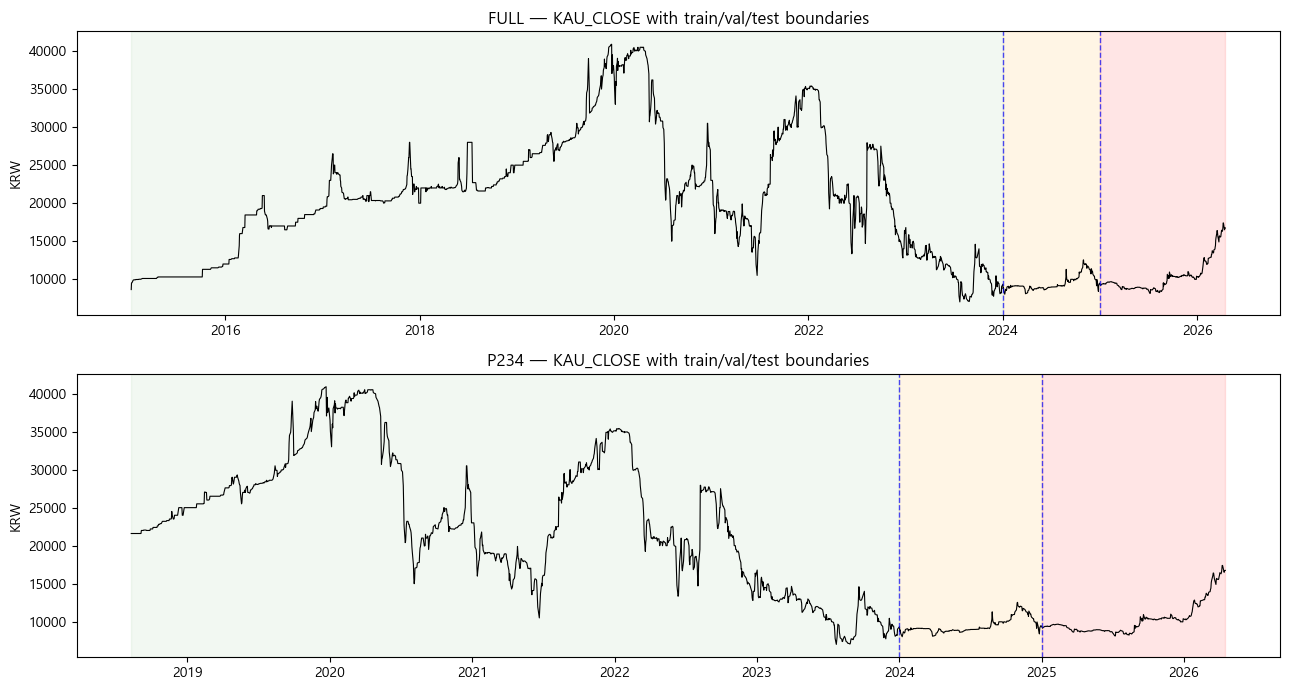

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)
for ax, (name, ds) in zip(axes, [('FULL', ds_full), ('P234', ds_p234)]):
    ax.plot(ds.index, ds['KAU_CLOSE'], color='black', lw=0.8)
    for d in DATE_SPLITS:
        ax.axvline(pd.Timestamp(d), color='blue', ls='--', lw=1.0, alpha=0.7)
    ax.set_title(f'{name} — KAU_CLOSE with train/val/test boundaries')
    ax.set_ylabel('KRW')
    # 경계 영역 색칠
    ax.axvspan(ds.index.min(), pd.Timestamp(DATE_SPLITS[0]), alpha=0.05, color='green')
    ax.axvspan(pd.Timestamp(DATE_SPLITS[0]), pd.Timestamp(DATE_SPLITS[1]), alpha=0.10, color='orange')
    ax.axvspan(pd.Timestamp(DATE_SPLITS[1]), ds.index.max(), alpha=0.10, color='red')
plt.tight_layout(); plt.savefig(FIG_DIR / '01_split.png'); plt.show()

## 6. feature_meta.json 저장

In [10]:
meta = {
    'y_col': Y_COL,
    'horizons': HORIZONS,
    'lag_y': LAG_Y,
    'roll_y_mean_windows': ROLL_Y_MEAN_WINDOWS,
    'roll_y_std_windows': ROLL_Y_STD_WINDOWS,
    'selected_exog': SELECTED_EXOG,
    'lag_x': LAG_X,
    'roll_x_mean_windows': ROLL_X_MEAN_WINDOWS,
    'date_splits': DATE_SPLITS,
    'warmup_drop': WARMUP_DROP,
    'drop_cols': DROP_COLS,
    'passthrough_cols': PASSTHROUGH_COLS,
    'scale_cols_full': result_full['scale_cols'],
    'scale_cols_p234': result_p234['scale_cols'],
}
(OUT_DIR / 'feature_meta.json').write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding='utf-8')
print('saved: data/features/feature_meta.json')

saved: data/features/feature_meta.json


In [11]:
print('=== 산출물 ===')
for f in sorted(OUT_DIR.glob('*')):
    if f.is_file():
        print(f'  {f.name:40s}  {f.stat().st_size/1024:8.1f} KB')

=== 산출물 ===
  .gitkeep                                       0.0 KB
  feature_meta.json                              3.9 KB
  master_full.csv                             1174.1 KB
  master_p234.csv                              804.8 KB
  scalers_full.pkl                               4.3 KB
  scalers_p234.pkl                               4.3 KB
  X_test_full.csv                              449.9 KB
  X_test_p234.csv                              452.2 KB
  X_train_full.csv                            3112.6 KB
  X_train_p234.csv                            1825.5 KB
  X_val_full.csv                               347.8 KB
  X_val_p234.csv                               350.0 KB
  Y_test_full.csv                               21.0 KB
  Y_test_p234.csv                               20.9 KB
  Y_train_full.csv                             145.7 KB
  Y_train_p234.csv                              85.2 KB
  Y_val_full.csv                                16.5 KB
  Y_val_p234.csv                    